In [ ]:
from simulation_fns import *
from summary_stat_fns import *
from helper import *
from distance_fns import *
from hellinger_distance import * 
import matplotlib.pyplot as plt 
import numpy as np
import pickle
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import pandas as pd

!python -u test.py --save_all

!python -u test2.py --out_prefix "data/simulations_2" --sequence_length 250000000 --nworkers 8

In [ ]:
# Read in the saved simulation results
with open("simulations_1_summary.pkl", "rb") as f:
    summary = pickle.load(f) # dictionary with models mapped to dictionaries of mean counts with CIs

with open("simulations_1_grouped.pkl", "rb") as f:
    grouped = pickle.load(f) # dictionary with models mapped to dictionaries of mean counts with CIs

In [40]:
# Set constants
ADMIX_START = 2000
ALPHA = 0.05
NINTERVALS = 10_000 # Discretization needs to be fine-grained enough to accurately estimate Hellinger distance!!!
# NINTERVALS = 2_000
MIN_TIME=0
MAX_TIME=80_000

# Redefine the models from the simulations here
admix_vals = [(0,ADMIX_START-1), (ALPHA,ADMIX_START-1), (ALPHA,ADMIX_START-50), (ALPHA,ADMIX_START-500), (ALPHA,ADMIX_START-1000), (ALPHA,0)]
models = [{
    "name":f"model_{i+1}",
    "dem_params":{
        "Na":10000, 
        "N1":10000, 
        "N2":2500, 
        "Tsplit":20000, 
        "Tadmix_start":ADMIX_START, 
        "Tadmix_end":t, 
        "m12":0, 
        "m21":alpha/(ADMIX_START-t)
    }
    } for i, (alpha, t) in enumerate(admix_vals)]

# Get the expected PMFs
expected = {}
for model in models:
    graph = build_2pop_admixture_demes(**model["dem_params"])
    demography = msprime.Demography.from_demes(graph)
    expected[model["name"]] = pair_coal_times_PMF(demography, nintervals=NINTERVALS, min_time=MIN_TIME, max_time=MAX_TIME)

In [ ]:
# Make the plots of expected vs. simulated for each model
width = 5
height = 4
fig, axes = plt.subplots(3, 2, figsize=(2*width, 3*height))
axes_flat = axes.flatten()

BLUE = '#2196F3'
ORANGE = '#FF9800'
RED = '#F44336'

titles = {
    "model_1":"No admixture",
    "model_2":"5% pulse",
    "model_3":"5%, 50 gens",
    "model_4":"5%, 500 gens",
    "model_5":"5%, 1000 gens",
    "model_6":"5%, 2000 gens"
}

x_num = np.linspace(MIN_TIME, MAX_TIME, NINTERVALS)
x_sim = np.linspace(MIN_TIME, MAX_TIME, 500)
for n, model in enumerate(models):
    pmf = expected[model["name"]][1] # the second curve is for (pop1, pop1)
    mu = summary[f"model_{n+1}"]["mean"][0]
    lo = summary[f"model_{n+1}"]["lower"][0]
    up = summary[f"model_{n+1}"]["upper"][0]
    # convert counts to densities - this method only works for LINEAR time scales I think
    scale = 500 / NINTERVALS # need to also take into account different interval sizes between numerical/simulated results
    mu = mu / mu.sum() * scale
    lo = lo / lo.sum() * scale
    up = up / up.sum() * scale
    axes_flat[n].plot(x_num[1:], pmf, color=RED, label="expected")
    axes_flat[n].plot(x_sim[1:], mu, color=BLUE, linestyle=':', label="simulation mean")
    axes_flat[n].fill_between(x_sim[1:], lo, up, alpha=0.2, color=BLUE, label="simulation 95% CI")
    # TO DO: make informative titles for lab meeting
    axes_flat[n].set_title(titles[model["name"]])
    axes_flat[n].legend()

fig.supxlabel("generations ago")
fig.supylabel("density")
plt.tight_layout()
plt.show()

In [ ]:
# Make plots to compare pairs of models
width = 5
height = 4
alpha = 0.2
fig, axes = plt.subplots(2, 3, figsize=(3*width, 2*height))
axes_flat = axes.flatten()

# hide all plots to start
for ax in axes_flat:
    ax.set_visible(False)

scale = 500 / NINTERVALS # need to take into account different interval sizes between numerical/simulated results
def add_to_plot(ax, x_num, x_sim, pmf, mu, lo, up, scale, color, title=None, label=None):
    # convert counts to densities - this method only works for LINEAR time scales I think
    mu = mu / mu.sum() * scale
    lo = lo / lo.sum() * scale
    up = up / up.sum() * scale
    ax.plot(x_num[1:], pmf, color=color, label=label)
    ax.plot(x_sim[1:], mu, color=color, linestyle=':')
    ax.fill_between(x_sim[1:], lo, up, alpha=alpha, color=color)
    ax.set_visible(True)
    ax.set_xlim(0, 40_000)  # adjust to where the curves diverge
    ax.set_title(title)
    ax.legend()

no_admix_pmf = expected["model_1"][1]
pulse_admix_pmf = expected["model_2"][1]

BLUE = '#2196F3'
ORANGE = '#FF9800'
RED = '#F44336'
# compare no admix versus pulse admix
add_to_plot(
    axes_flat[0], x_num, x_sim, no_admix_pmf, 
    summary["model_1"]["mean"][0], 
    summary["model_1"]["lower"][0], 
    summary["model_1"]["upper"][0],
    scale, RED, label="No admixture"
)
add_to_plot(
    axes_flat[0], x_num, x_sim, pulse_admix_pmf, 
    summary["model_2"]["mean"][0], 
    summary["model_2"]["lower"][0], 
    summary["model_2"]["upper"][0],
    scale, BLUE, title="Pulse", label="Pulse"
)

labels = ["50 gens", "500 gens", "1000 gens", "2000 gens"]
# compare different duration pulses to single generation pulse
for i in range(4):
    add_to_plot(
        axes_flat[i+1], x_num, x_sim, pulse_admix_pmf, 
        summary["model_2"]["mean"][0], 
        summary["model_2"]["lower"][0], 
        summary["model_2"]["upper"][0],
        scale, BLUE, label="Pulse"
    )
    add_to_plot(
        axes_flat[i+1], x_num, x_sim, 
        expected[f"model_{i+3}"][1], 
        summary[f"model_{i+3}"]["mean"][0], 
        summary[f"model_{i+3}"]["lower"][0], 
        summary[f"model_{i+3}"]["upper"][0],
        scale, ORANGE, label=labels[i]
    )
    add_to_plot(
        axes_flat[i+1], x_num, x_sim, no_admix_pmf, 
        summary["model_1"]["mean"][0], 
        summary["model_1"]["lower"][0], 
        summary["model_1"]["upper"][0],
        scale, RED, title=labels[i], label="No admixture"
    )

fig.supxlabel("generations ago")
fig.supylabel("density")
plt.tight_layout()
plt.show()

In [ ]:
# Make plots to compare pairs of models
width = 4
height = 4
alpha = 0.3
fig, axes = plt.subplots(2, 3, figsize=(3*width, 2*height))
axes_flat = axes.flatten()

# hide all plots to start
for ax in axes_flat:
    ax.set_visible(False)

model_names = {
    "model_1":"No admixture",
    "model_2":"Pulse",
    "model_3":"50 gens",
    "model_4":"500 gens",
    "model_5":"1000 gens",
    "model_6":"2000 gens"
}
scale = 500 / NINTERVALS # need to take into account different interval sizes between numerical/simulated results
NCOUNTS = 1_000 # ensure that every LRT uses the same number of pairwise coalescence times in the counts array
def add_to_plot(ax, null, alt):
    null_counts = np.stack(grouped[null])[:,0,:]
    alt_counts = np.stack(grouped[alt])[:,0,:]
    lr_null, lr_alt, threshold, power = LR(
        expected[null][1], 
        expected[alt][1], 
        null_counts, 
        alt_counts, 
        # total_counts=NCOUNTS
        total_counts=None
    )
    # Add to plot
    ax.hist(lr_null, alpha=0.3, label=model_names[null])
    ax.hist(lr_alt, alpha=0.3, label=model_names[alt])
    ax.axvline(x=threshold)
    # TO DO: set informative plot titles for lab meeting
    ax.set_title(f"power={(power*100):.2f}%")
    ax.legend()
    ax.set_visible(True)

# compare no admix versus pulse admix
add_to_plot(
    axes_flat[0], "model_1", "model_2"
)

# compare different duration pulses to single generation pulse
for i in range(4):
    add_to_plot(
        axes_flat[i+1], "model_2", f"model_{i+3}"
    )
    
fig.supxlabel("2 x log likelihood ratio")
fig.supylabel("counts")
fig.suptitle("Distributions of Likelihood Ratios")
plt.tight_layout()
plt.show()

In [ ]:
# Sample from the theoretical distributions - does LRT provide similar results? Can we estimate bounds based on Hellinger distance?
def sample_counts(pmf, ntrials=100, n=1_000, seed=42):
    pmf = pmf / pmf.sum() # normalize in case it doesn't perfectly sum to 1
    rng = np.random.default_rng(seed=seed)
    counts = rng.multinomial(n, pmf, size=ntrials)
    return counts

def estimate_H2(pmf1, pmf2):
    return np.square(np.sqrt(pmf1) - np.sqrt(pmf2)).sum()

def compare_models(null, alt, ax=None):
    params = {
        "P":{"pmf":expected[null][1]},
        "Q":{"pmf":expected[alt][1]}
    }
    n_vals = [n for n in range(1,5000,50)]
    # (bayes_error, upper bound, TVD_upper, TVD_lower)
    outputs = np.array([list(bayes_error(
        params, 
        loglik_fn=pair_coal_times_loglik,
        sample_fn=sample_counts,
        H2_fn=estimate_H2,
        ntrials=1000, n=n)) for n in n_vals]) 
    fig, ax = plot_bayes_error(
        n_vals, 
        outputs[:,0], outputs[:,1], outputs[:,3], outputs[:,2],
        title=f"{model_names[null]} vs. {model_names[alt]}",
        ax=ax
    )
    return fig, ax

In [ ]:
# Plot bayes error bounds for model comparisons
nrows, ncols = 2, 3
fig_grid, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.flatten()

compare_models("model_1", "model_2", ax=axes[0])
compare_models("model_2", "model_3", ax=axes[1])
compare_models("model_2", "model_4", ax=axes[2])
compare_models("model_2", "model_5", ax=axes[3])
compare_models("model_2", "model_6", ax=axes[4])

axes[-1].set_visible(False)  # hide the empty 6th cell
fig.tight_layout()
plt.show()

In [ ]:
# Read in the saved simulation results
with open("data/simulations_3_grouped.pkl", "rb") as f:
    grouped = pickle.load(f) # dictionary with models mapped to dictionaries of mean counts with CIs

In [35]:
# PLOT BAYES ERROR VERSUS EXPECTED BOUNDS FOR SPARSELY SAMPLED PAIRWISE COALESCENCE TIME DATA

# grouped is a dictionary with an entry for each model
# grouped["model_i"] is a list of length NUM_REPLICATES
# each element of the list is an array of dimensions (num_trees, num_sample_sets, binned_counts)

def estimate_H2(pmf1, pmf2):
    return np.square(np.sqrt(pmf1) - np.sqrt(pmf2)).sum()

# plotting function from Claude :)
def plot_bayes_bounds(ax, bounds, bayes_error):
    """
    Plot Bayes error estimates as boxplots with individual points,
    and bounds as horizontal lines, against number of samples.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
    bounds : np.ndarray, shape (N, 3)
        Columns: [n_samples, lower_bound, upper_bound]
    bayes_error : np.ndarray, shape (N, S)
        S estimates of Bayes error for each of N sample counts
    """
    n_samples = bounds[:, 0]
    lower = bounds[:, 1]
    upper = bounds[:, 2]
    N = len(n_samples)

    fig = ax.figure

    # Use integer positions for spacing, then relabel with actual sample counts
    positions = np.arange(N)
    width = 0.4  # half-width of the bound bars

    # --- Boxplots ---
    bp = ax.boxplot(
        [bayes_error[i] for i in range(N)],
        positions=positions,
        widths=0.35,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="#4C72B0", alpha=0.6, linewidth=1.2),
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(linewidth=1.2, color="#4C72B0"),
        capprops=dict(linewidth=1.2, color="#4C72B0"),
    )

    # --- Individual points (jittered) ---
    rng = np.random.default_rng(42)
    for i in range(N):
        jitter = rng.uniform(-0.12, 0.12, size=bayes_error.shape[1])
        ax.scatter(
            positions[i] + jitter,
            bayes_error[i],
            color="#4C72B0",
            alpha=0.4,
            s=18,
            zorder=3,
            linewidths=0,
        )

    # --- Bound bars (horizontal lines with caps) ---
    for i in range(N):
        x = positions[i]
        lo, hi = lower[i], upper[i]

        # Vertical span line
        ax.plot(
            [x, x], [lo, hi],
            color="#DD8452",
            linewidth=2,
            zorder=4,
            solid_capstyle="round",
        )
        # End caps
        for y in (lo, hi):
            ax.plot(
                [x - width / 2, x + width / 2], [y, y],
                color="#DD8452",
                linewidth=2,
                zorder=4,
                solid_capstyle="round",
            )

    # --- Axes formatting ---
    ax.set_xticks(positions)
    ax.set_xticklabels([f"{int(n):,}" for n in n_samples], rotation=45, ha="right")
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Bayes error")
    ax.set_xlim(-0.6, N - 0.4)

    # --- Legend ---
    box_patch = mpatches.Patch(facecolor="#4C72B0", alpha=0.7, label="Bayes error estimates")
    bound_line = mpatches.Patch(facecolor="#DD8452", label="Error bounds")
    ax.legend(handles=[box_patch, bound_line], framealpha=0.9)

    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    return fig, ax

def compare_models_from_sim(expected, simulated, num_trees, ax, samples_per_tree=5, model1="model_1", model2="model_2", s0=1, maxn=100_000):
    # Get expected bounds
    bounds = np.zeros((len(num_trees), 3)) # sample size, lower, upper
    for i in range(len(num_trees)):
        # Compute the expected bounds
        n = num_trees[i]*samples_per_tree
        H2 = estimate_H2(expected[model1][s0], expected[model2][s0])
        H2n = 2 * (1 - (1-H2/2)**n) 
        TVD_bounds = np.array([np.sqrt(H2n), H2n/2]) # upper, lower
        TVD_bounds = 0.5 - TVD_bounds/2 # lower, upper
        TVD_bounds = np.maximum(TVD_bounds, 0)
        bounds[i,0] = n
        bounds[i,1:] = TVD_bounds

    # Also print best bounds achievable for a full genome
    H2n_max = 2 * (1 - (1-H2/2)**maxn)
    best_bounds = np.maximum(0.5 - np.array([np.sqrt(H2n), H2n/2]) / 2, 0)*100
    print(f"Best bounds for human genome assuming 2GB unmasked sequence: {best_bounds[0]:.2f}% to  {best_bounds[1]:.2f}%")
    
    # Estimate from the simulated data
    counts1 = np.array(simulated[model1]) # (num_reps, num_trees, nss, binned_counts)
    counts2 = np.array(simulated[model2])
    nreps, nss = counts1.shape[0], counts1.shape[2]
    bayes_error = np.zeros((len(num_trees), nss))
    for i, n in enumerate(num_trees):
        for s in range(nss):
            # LRT statistic
            lambda_1 = pair_coal_times_loglik(counts1[:,i,s], expected[model1][s0]) - pair_coal_times_loglik(counts1[:,i,s], expected[model2][s0])
            lambda_2 = pair_coal_times_loglik(counts2[:,i,s], expected[model1][s0]) - pair_coal_times_loglik(counts2[:,i,s], expected[model2][s0])
            # Bayes error
            alpha = (lambda_1 < 0).sum() /  nreps
            beta = (lambda_2 > 0).sum() / nreps
            bayes_error[i, s] = (alpha + beta) / 2

    # Make box plots
    fig, ax = plot_bayes_bounds(ax, bounds, bayes_error)
    return fig, ax


Best bounds for human genome assuming 2GB unmasked sequence: 0.00% to  0.00%
Best bounds for human genome assuming 2GB unmasked sequence: 33.17% to  47.17%
Best bounds for human genome assuming 2GB unmasked sequence: 28.93% to  45.56%
Best bounds for human genome assuming 2GB unmasked sequence: 21.00% to  41.59%
Best bounds for human genome assuming 2GB unmasked sequence: 9.76% to  33.81%


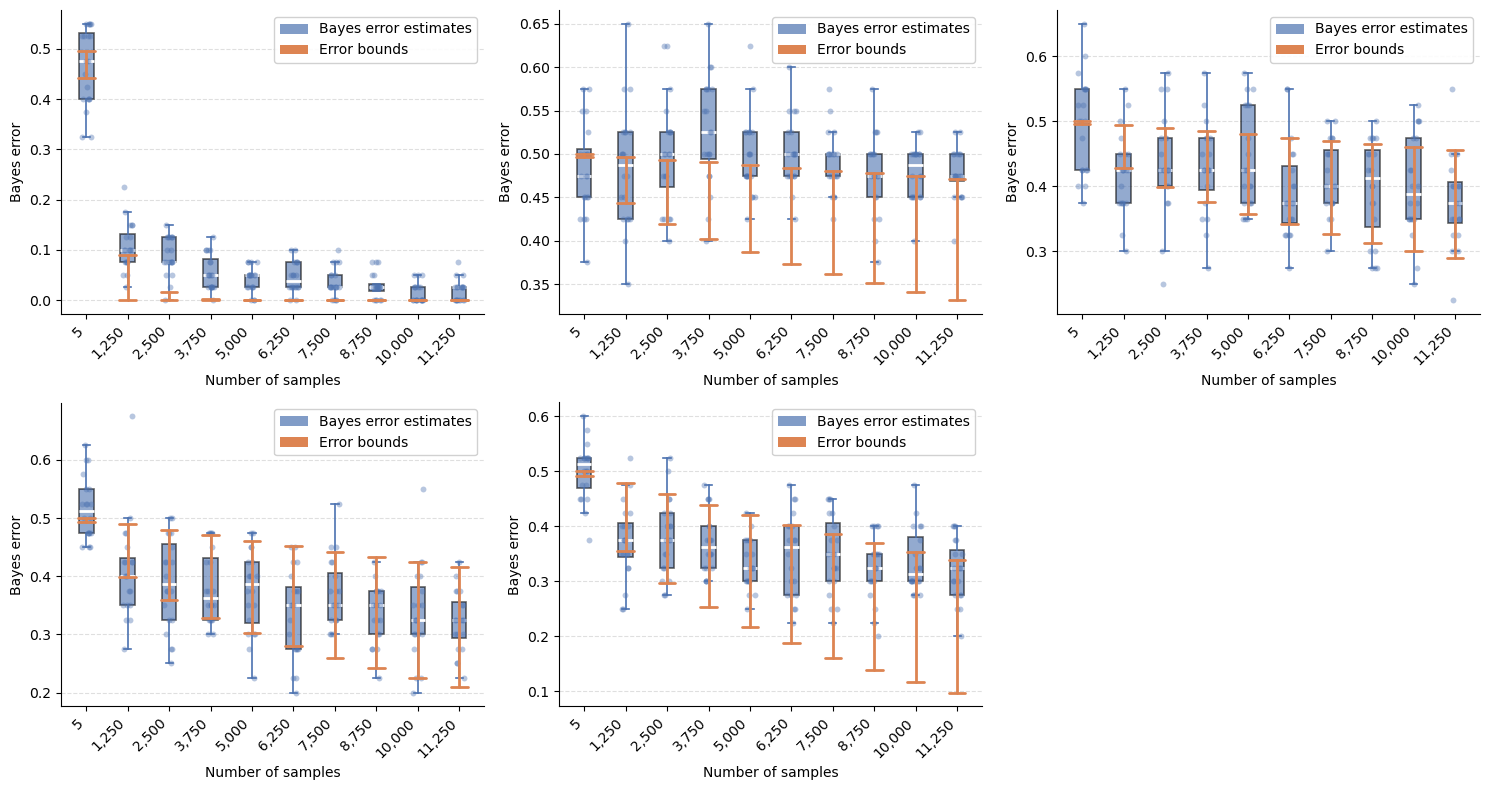

In [41]:
# Plot bayes error bounds for model comparisons
nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.flatten()

max_trees = 250_000_000 // 100_000
num_trees = np.arange(0, max_trees, max_trees // 10, dtype=np.int32)
num_trees[0] = 1

for i in range(5):
    if i == 0:
        compare_models_from_sim(expected, grouped, num_trees, axes[i], model1="model_1", model2="model_2")
    else:
        compare_models_from_sim(expected, grouped, num_trees, axes[i], model1="model_2", model2=f"model_{i+2}")

axes[-1].set_visible(False)  # hide the empty 6th cell
fig.tight_layout()
plt.show()